In [123]:
import pandas as pd
df = pd.read_csv(r'C:\Users\rdeep\OneDrive\Desktop\AI\ML\cgpa_iq_placement_100.csv')

In [124]:
df.head()

,CGPA,IQ,Placement
0,8.20,83,1
1,8.71,111,1
2,6.12,93,1
3,8.38,91,1
4,7.95,84,1


In [125]:
df.shape

(100, 3)

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CGPA       100 non-null    float64
 1   IQ         100 non-null    int64  
 2   Placement  100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


# EDA

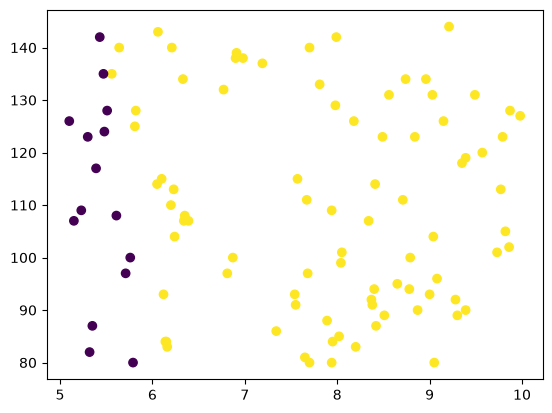

In [127]:
import matplotlib.pyplot as plt
plt.scatter(df["CGPA"], df["IQ"], c = df["Placement"])
plt.show()

# Feature Selection

In [128]:
X = df.iloc[:, 0:2]
X

,CGPA,IQ
0,8.20,83
1,8.71,111
2,6.12,93
3,8.38,91
4,7.95,84
...,...,...
95,8.37,92
96,5.30,123
97,9.00,93
98,6.24,104


In [129]:
y = df.iloc[:, -1]
y

0     1
1     1
2     1
3     1
4     1
     ..
95    1
96    0
97    1
98    1
99    1
Name: Placement, Length: 100, dtype: int64

# Train test Split

In [130]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.1)

In [131]:
X_train

,CGPA,IQ
3,8.38,91
30,8.05,101
64,6.87,100
0,8.20,83
45,6.81,97
...,...,...
61,9.35,118
97,9.00,93
48,5.76,100
78,9.98,127


In [132]:
y_train

3     1
30    1
64    1
0     1
45    1
     ..
61    1
97    1
48    0
78    1
74    1
Name: Placement, Length: 90, dtype: int64

# Scalling

In [133]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [134]:
X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.54509181, -0.94324053],
       [ 0.32117443, -0.42338966],
       [-0.47949985, -0.47537474],
       [ 0.42295505, -1.35912123],
       [-0.5202121 , -0.63133001],
       [ 0.87757519, -0.99522562],
       [-1.02911524,  1.75998402],
       [ 1.55611271,  0.9802077 ],
       [-1.68051126,  0.87623753],
       [-0.26236784,  1.44807349],
       [ 0.82329219, -0.47537474],
       [ 0.51795031, -0.11147913],
       [ 0.93864357,  1.29211823],
       [ 0.06333017,  0.09646122],
       [ 0.57223331, -1.15118088],
       [ 0.15832542,  1.24013314],
       [-0.80519786, -0.11147913],
       [ 0.81650681, -0.78728527],
       [-0.16058721, -1.20316597],
       [ 0.25332067, -1.30713614],
       [ 0.61973093,  0.72028227],
       [-0.96126149, -1.35912123],
       [-1.42945237,  1.34410332],
       [ 0.2465353 , -0.00750896],
       [ 0.53830643, -0.89125544],
       [-0.90697848, -0.26743439],
       [ 0.4093843 ,  0.87623753],
       [-1.31410099,  1.60402875],
       [ 1.50182971,

In [135]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.31438905, -0.52735983],
       [-0.45235835,  1.55204367],
       [-0.5473536 ,  1.18814805],
       [-0.83233936, -0.05949404],
       [ 0.04975942, -1.46309141],
       [ 0.98614119,  1.13616297],
       [-1.40231087,  0.9802077 ],
       [-0.00452358,  0.30440157],
       [ 1.0675657 ,  0.87623753],
       [-1.19874962,  0.82425244]])

# Train the Model

In [136]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# Model Evluation from Accuracy 

In [137]:
y_predict = clf.predict(X_test)
y_predict

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [138]:
y_test

63    1
51    1
93    1
33    1
52    1
36    1
14    0
87    1
20    1
27    1
Name: Placement, dtype: int64

In [143]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

1.0

<Axes: >

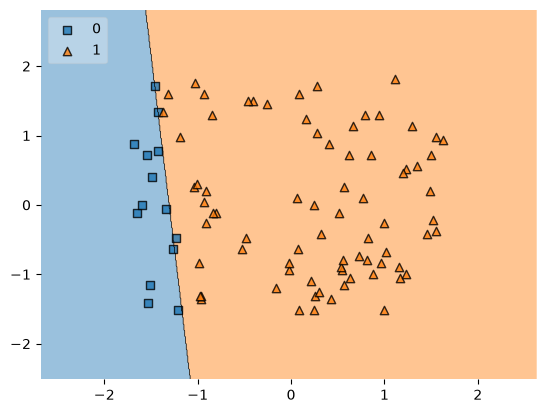

In [148]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf = clf, legend = 2)